# 文章データ分析
## データセットの読み込み
各行が1通のメールに対応している
- type: メールの分類
  - 1: スパム (spam)
  - 0: スパムではない (ham)
- text: 本文

In [1]:
import pandas as pd

# email.csv を読み込んで，データフレーム形式で email に代入
email = pd.read_csv("email.csv")

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,Go until jurong point crazy.. Available only ...
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,Nah I don't think he goes to usf he lives aro...
...,...,...
5566,0,Why don't you wait 'til at least wednesday to ...
5567,0,Huh y lei...
5568,1,REMINDER FROM O2: To get 2.50 pounds free call...
5569,1,This is the 2nd time we have tried 2 contact u...


## スパムメールの分析
- ワードクラウドを作成して，頻出単語を可視化する

In [2]:
# スパムメール (type が 1) の行だけを選んで spam に代入
spam = email[email["type"]==1]

# スパムではないメール (type が 0) の行だけを選んで ham に代入
ham = email[email["type"]==0]

# 内容の確認（spam と ham を順に表示）
display(spam)
display(ham)

,type,text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,SIX chances to win CASH! From 100 to 20 000 po...
...,...,...
5539,1,Want explicit SEX in 30 secs? Ring 02073162414...
5542,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5549,1,Had your contract mobile 11 Mnths? Latest Moto...
5568,1,REMINDER FROM O2: To get 2.50 pounds free call...


,type,text
0,0,Go until jurong point crazy.. Available only ...
1,0,Ok lar... Joking wif u oni...
3,0,U dun say so early hor... U c already then say...
4,0,Nah I don't think he goes to usf he lives aro...
6,0,Even my brother is not like to speak with me. ...
...,...,...
5564,0,Ok lor... Sony ericsson salesman... I ask shuh...
5565,0,Ard 6 like dat lor.
5566,0,Why don't you wait 'til at least wednesday to ...
5567,0,Huh y lei...


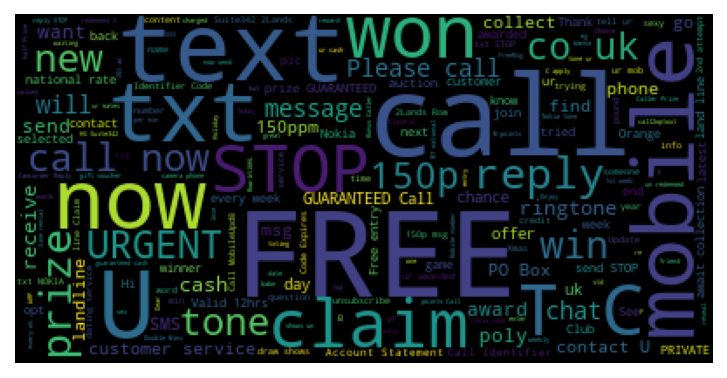

In [3]:
# 全てのスパムメールの本文を (空白文字をはさんで) 連結して spam_words に代入
spam_words = " ".join(spam["text"])

# WordCloud オブジェクトを spam_wc に代入
from wordcloud import WordCloud
spam_wc = WordCloud()

# spam_words を元にして，spam_wc 内の WordCloud オブジェクトにワードクラウドを生成する
spam_wc.generate(spam_words)

# 生成したイメージを，pyplot を使って表示する
import matplotlib.pyplot as plt
plt.figure(dpi=150)     # 大きなイメージで表示する
plt.imshow(spam_wc)
plt.axis("off")         # 軸目盛りの非表示
plt.show()

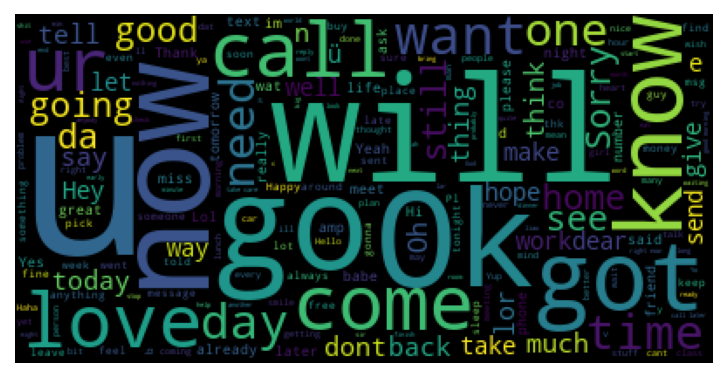

In [4]:
# スパムではないメールでも，同様の操作を行う
ham_words = " ".join(ham["text"])
ham_wc = WordCloud()
ham_wc.generate(ham_words)
plt.figure(dpi=150)
plt.imshow(ham_wc)
plt.axis("off")
plt.show()

## スパムメールフィルターの作成
### 前処理

In [5]:
# メール本文の大文字を全て小文字に変換
email["text"] = email["text"].str.lower()

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,go until jurong point crazy.. available only ...
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,nah i don't think he goes to usf he lives aro...
...,...,...
5566,0,why don't you wait 'til at least wednesday to ...
5567,0,huh y lei...
5568,1,reminder from o2: to get 2.50 pounds free call...
5569,1,this is the 2nd time we have tried 2 contact u...


In [6]:
# ストップワードの除去
stop_words = ["the", "a", "an", "in", "on", "at", "by", "for", "of", "to", "is", "are", "am"]
for w in stop_words:
    email["text"] = email["text"].str.replace(f" {w} ", " ")

# 内容の確認（emailの表示）
display(email)

,type,text
0,0,go until jurong point crazy.. available only ...
1,0,ok lar... joking wif u oni...
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say so early hor... u c already then say...
4,0,nah i don't think he goes usf he lives around...
...,...,...
5566,0,why don't you wait 'til least wednesday see if...
5567,0,huh y lei...
5568,1,reminder from o2: get 2.50 pounds free call cr...
5569,1,this 2nd time we have tried 2 contact u. u hav...


### 形態素解析
(というか，単語とその出現頻度をカウントしているだけ)

- CountVectorizer オブジェクトを使用する
  - 単語のリストを作成する
  - 各入力文に対して，どの単語が何回出現したかの情報をテーブルの形で生成する
    - 行が入力データ (メール) に対応
    - 列は各単語に対応
    - 各フィールドの値は，その行の入力データに，その列の語が出現した回数
  - あらかじめ，単語の最少出現回数 (min_df) を決めておくことができる

In [7]:
# CountVectorizer オブジェクトを生成して vector に代入
from sklearn.feature_extraction.text import CountVectorizer
vector = CountVectorizer(min_df=3)

# email["text"] で3回以上出現した単語のリストを作成する
vector.fit(email["text"])

# (3回以上出現した)単語数の表示
print("単語数：", len(vector.vocabulary_))

単語数： 2817


In [8]:
# email["text"] の各文ごとの，単語出現回数の表を text_vec に代入
text_vec = vector.transform(email["text"])

# 内容の確認（text_vec の表示，さらに "free" の列だけ抜粋して表示
text_vec_df = pd.DataFrame(text_vec.toarray(), columns=vector.get_feature_names_out())
display(text_vec_df)
display(text_vec_df["free"])

,00,000,02,0207,03,04,05,06,07xxxxxxxxx,0800,...,yr,yrs,yummy,yun,yup,zed,áeall,áegot,áestill,áewan
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5566,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


0       0
1       0
2       1
3       0
4       0
       ..
5566    0
5567    0
5568    1
5569    0
5570    0
Name: free, Length: 5571, dtype: int64

### スパム分類AIの作成
- ナイーブベイズというモデルを使用する (<u>「素朴な」ベイズ推定</u>という方法を用いる)

In [9]:
x = text_vec        # 説明変数 (メールごとの単語出現回数ベクトル)
y = email['type']   # 目的変数 (メールごとのスパムかそうでないかのデータ)

# データをランダムに分割するためのライブラリ train_test_split をインポートする
from sklearn.model_selection import train_test_split

# 元データを訓練データとテストデータに分割する
#   train_size：    訓練データの割合または個数 (この例では70%)
#   test_size：     テストデータの割合または個数 (この例では30%)
#   random_state：  乱数の seed (種子)— 0以上4294967295以下の任意の整数 (同じ値に対しては，毎回同じように分割される)
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=0)

# x_train, y_train: 訓練データの説明変数，目的変数
# x_test, y_test:   テストデータの説明変数，目的変数
print("訓練データのデータ数:　", len(y_train))
print("テストデータのデータ数:", len(y_test))

訓練データのデータ数:　 3899
テストデータのデータ数: 1672


In [10]:
# BernoulliNB オブジェクト (ナイーブベイズモデル) を生成して model に代入する
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()

# 先の訓練データ (x_train, y_train) で model に学習させる
model.fit(x_train, y_train)

# 学習結果の確認
#   テストデータ (x_test, y_test)  を判定させ，
#   正解率を計算して表示
print(model.score(x_test, y_test))

0.9850478468899522


In [22]:
# 学習させたモデルを使って，スパムかどうか判定する関数を定義する
def spam_check(text, md):
    # テキスト text を 1行1列のデータフレームに変換
    df = pd.DataFrame([text])
    # vector を使って，単語出現回数ベクトルを生成して vec に代入
    vec = vector.transform(df[0])
    # モデル md を使って，vec を判定させる
    # predict は判定のための命令
    return md.predict(vec)[0]

# 上で定義した関数を使い，
# 学習サンプルではない入力に対して判定させてみる
# 1 - スパム， 0 - スパムではない
print(spam_check("I cant pick the phone right now", model))     # -> 0 (ham)
print(spam_check("Congratulations ur awarded $500.", model))    # -> 1 (spam)

0
1


In [48]:
print(spam_check("Win the final bet and get a free entry ticket.", model))      # -> 1 (spam)
print(spam_check("If I win the final bet, I get a free entry ticket.", model))  # -> 1 (spam)
print(spam_check("If I win the last bet, I get a free entry ticket.", model))   # -> 0 (ham)

1
1
0


In [59]:
print(spam_check("Congratulations! ur awarded $500.", model))
print(spam_check("Say congratulations to us. We're awarded $500.", model))
print(spam_check("Say congratulations to me. I'm awarded $500.", model))

1
1
0
